<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH09/CH09_NB02_MOE_Upcycling_TopK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 9: Mixture of Experts (MoE)
### Notebook 2: Upcycling a pre-trained expert

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
- HuggingFaceTB/SmolLM2-1.7B-Instruct
- oopere/SmolLM2-1.7B-ClinicalNER

_____
In Notebook 1, you trained both an MoE expert and a router. In this notebook, you reuse the clinical MLP learned in Chapter 7 and transplant it directly as Expert 1.

This upcycling workflow skips full expert training and focuses on router adaptation, then evaluates general behavior, clinical extraction quality, and routing decisions.

# Setting up the notebook

This section installs dependencies, imports modules, and defines utility and configuration values used throughout the notebook.

In [2]:
!pip install -q \
    transformers==5.0.0 \
    datasets==4.0.0 \
    accelerate==1.12.0 \
    langdetect \
    codecarbon \
    lm-eval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import copy
import json
import random
import gc
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Running on:", DEVICE)

Running on: cuda


In [4]:
if os.path.exists('../utils.py') and not os.path.exists('utils.py'):
    import shutil
    shutil.copy('../utils.py', 'utils.py')
if not os.path.exists('utils.py'):
    import subprocess
    subprocess.run(['wget', '-q',
        'https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py'],
        check=True)

from utils import model_evaluation

In [5]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


## Configuration

Centralized parameters for reproducible experiments. Adjust values here before running the workflow.

In [6]:
# Core model configuration
BASE_MODEL_ID = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
CLINICAL_MODEL_ID = "oopere/SmolLM2-1.7B-ClinicalNER"

# Runtime and training settings
EPOCHS = 3
#LAYERS_TO_MODIFY = range(13, 24)  # Last 11 layers of the 24-layer model

# Dataset sizes
CLINICAL_TRAIN_SAMPLES = 300
GENERAL_TRAIN_SAMPLES = 300

# Sequence and generation settings
MAX_TRAIN_LENGTH = 512
MAX_GENERAL_TEST_TOKENS = 50
MAX_CLINICAL_TEST_TOKENS = 150
MAX_EVAL_TOKENS = 400

#Benchmarks configuration
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa"
]
BENCHMARK_LIMIT = None

# Set to True to run lm-eval benchmarks on each model variant.
# Benchmarks add significant runtime; keep False to skip and only evaluate
# schema compliance.
RUN_FULL_BENCHMARKS = True

# Reproducibility and runtime
SEED = 42
set_seed(SEED)
print(f"Configuration loaded | seed={SEED} | epochs={EPOCHS}")

Configuration loaded | seed=42 | epochs=3


In [7]:
def clear_gpu_cache():
    """Clear GPU cache completely"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

## Workflow: Building the upcycled MoE

### Loading the two models

We need both models in memory only for a short phase. After extracting the clinical MLP weights from the Chapter 7 model and transplanting them into the MoE blocks, we release that model before router training.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

# The base model becomes Expert 0 (general knowledge).
print("Loading base model...")
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID,
                                             torch_dtype=torch.float16)
model.to(DEVICE)

print(f"\nBase model     : {sum(p.numel() for p in model.parameters()):,} parameters")

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading base model...


model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


Base model     : 1,711,376,384 parameters


## The MoE block

The class is identical to Notebook 1 with one addition: an optional
`clinical_mlp` argument. When provided, Expert 1 is initialised directly
from those weights instead of from a copy of the base MLP.

That single optional argument is the entire difference between training an
expert from scratch and reusing one you already have.

In [9]:
class TrainableTopKMoE(nn.Module):
    """Top-k soft/hard MoE block with a configurable number of experts.

    Args:
        original_mlp:  the original MLP from the decoder layer (becomes Expert 0).
        hidden_size:   model hidden dimension, used to size the router.
        num_experts:   total number of experts in this block.
        top_k:         number of experts considered per token during inference
                       (must be <= num_experts). Mutable after construction —
                       e.g. `layer.top_k = 1` to switch behaviour without rebuilding.
        extra_experts: optional list of pre-trained MLPs to use as Expert 1..N.
                       Missing slots (if len(extra_experts) < num_experts - 1)
                       are filled with copies of original_mlp, same fallback
                       behaviour as before.
    """
    def __init__(self, original_mlp, hidden_size, num_experts=2, top_k=2,
                 extra_experts=None):
        super().__init__()
        assert top_k <= num_experts, "top_k must be lower than number of experts"

        target_dtype  = next(original_mlp.parameters()).dtype
        target_device = next(original_mlp.parameters()).device

        self.num_experts = num_experts
        self.top_k = top_k

        experts_list = [original_mlp]
        extra_experts = extra_experts or []
        for e in extra_experts:
            experts_list.append(
                copy.deepcopy(e).to(device=target_device, dtype=target_dtype)
            )
        # Fill any remaining slots with copies of the original MLP.
        while len(experts_list) < num_experts:
            experts_list.append(
                copy.deepcopy(original_mlp).to(device=target_device, dtype=target_dtype)
            )

        self.experts = nn.ModuleList(experts_list)
        self.router = nn.Linear(hidden_size, num_experts, bias=False,
                                dtype=target_dtype, device=target_device)
        self.last_routing = None

    def forward(self, hidden_states):
        router_logits = self.router(hidden_states)

        if self.training:
            # Dense soft routing — gradients flow through the weighted sum
            # over ALL experts. top_k is not used here.
            routing_weights = F.softmax(
                router_logits.float(), dim=-1).to(hidden_states.dtype)

            output = torch.zeros_like(hidden_states)
            for i in range(self.num_experts):
                output = output + self.experts[i](hidden_states) * \
                    routing_weights[..., i].unsqueeze(-1)

            self.last_routing = routing_weights.detach()

        else:
            # Sparse top-k routing — only the selected experts run.
            topk_values, topk_indices = torch.topk(
                router_logits, k=self.top_k, dim=-1)
            # Softmax renormalised over just the selected experts.
            topk_weights = F.softmax(
                topk_values.float(), dim=-1).to(hidden_states.dtype)

            output = torch.zeros_like(hidden_states)
            full_weights = torch.zeros_like(router_logits)

            for expert_idx in range(self.num_experts):
                # Mask: which tokens picked this expert, in any top-k slot.
                is_selected = (topk_indices == expert_idx)
                if not is_selected.any():
                    continue
                token_mask = is_selected.any(dim=-1)
                weight_per_token = (topk_weights * is_selected).sum(dim=-1)

                expert_out = self.experts[expert_idx](hidden_states[token_mask])
                output[token_mask] += expert_out * \
                    weight_per_token[token_mask].unsqueeze(-1)
                full_weights[..., expert_idx] = weight_per_token

            self.last_routing = full_weights.detach()

        return output



## Transplanting the pre-trained expert

For each target layer we extract the MLP from the chapter-7 model and pass
it as `clinical_mlp`. The base model keeps its original MLP as Expert 0.
After the transplant we delete the clinical model to free GPU memory.

In [10]:
LAYERS_TO_MODIFY = range(model.config.num_hidden_layers)


In [11]:
# Extract only the MLP weights from the chapter-7 model — CPU only.
hidden_size = model.config.hidden_size
print("Extracting clinical MLPs from chapter-7 model...")
clinical_mlps = {}
clinical_model = AutoModelForCausalLM.from_pretrained(
    CLINICAL_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cpu"
)
for layer_idx in LAYERS_TO_MODIFY:
    clinical_mlps[layer_idx] = copy.deepcopy(
        clinical_model.model.layers[layer_idx].mlp
    )

# Chapter-7 model has served its purpose — free the memory before surgery.
del clinical_model
torch.cuda.empty_cache()
print("Clinical model unloaded.")

# Now perform the surgery with only one model in GPU memory.
for layer_idx in LAYERS_TO_MODIFY:
    base_mlp = model.model.layers[layer_idx].mlp
    model.model.layers[layer_idx].mlp = TrainableTopKMoE(
        base_mlp, hidden_size, num_experts=2, top_k=2,
        extra_experts=[clinical_mlps[layer_idx]]
    )

del clinical_mlps
torch.cuda.empty_cache()
print(f"Transplant complete: {len(LAYERS_TO_MODIFY)} layers using chapter-7 Expert 1.")

Extracting clinical MLPs from chapter-7 model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Clinical model unloaded.
Transplant complete: 24 layers using chapter-7 Expert 1.


In [12]:
gc.collect()

137

## Freezing strategy

In Notebook 1 you unfroze Expert 1 AND the router. Here Expert 1 is already
trained — freezing it is not only possible but correct. The only parameters
that need to learn are the router weights, one linear layer per MoE block.

In [13]:
# Freeze the entire model.
for param in model.parameters():
    param.requires_grad_(False)

# Unfreeze only the routers — Expert 1 stays frozen.
for layer_idx in LAYERS_TO_MODIFY:
    for param in model.model.layers[layer_idx].mlp.router.parameters():
        param.requires_grad_(True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total parameters  : {total:,}")
print(f"Trainable (router): {trainable:,}  ({trainable/total:.4%})")
print()

Total parameters  : 2,919,434,240
Trainable (router): 98,304  (0.0034%)



## Training data

The router needs to see both clinical and general text so it can learn the
contrast: Expert 1 reduces loss on clinical prompts; Expert 0 reduces it on
general ones. We use the same clinical dataset as chapter 7 plus a small
set of general-purpose sentences.

In [14]:
dataset = load_dataset("oopere/clinical-ner-qdora", split="train")
train_dataset = dataset.select(range(300))

# Clinical prompts — same format the chapter-7 model was trained on.
clinical_prompts = []
for item in train_dataset:
    label = json.loads(
        item['label']) if isinstance(item['label'], str) else item['label']
    messages = [
        {"role": "system",    "content": "Extract:"},
        {"role": "user",      "content": item['note']},
        {"role": "assistant", "content": json.dumps(label, indent=2)}
    ]
    clinical_prompts.append(
        tokenizer.apply_chat_template(messages, tokenize=False,
                                      add_generation_prompt=False)
    )

# Load SmolTalk — the same data SmolLM2 was instruction-tuned on
smoltalk = load_dataset("HuggingFaceTB/smoltalk", "all", split="train")

# Keep only single-turn conversations (one user + one assistant message)
# and short enough to be comparable to clinical prompts
smoltalk_single = smoltalk.filter(
    lambda x: len(x["messages"]) == 2 and                    # single turn only
              len(x["messages"][0]["content"]) < 300          # no huge prompts
)

general_subset = smoltalk_single.select(range(300))

# Build general_prompts directly from the messages column
general_prompts = []
for item in general_subset:
    general_prompts.append(
        tokenizer.apply_chat_template(
            item["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    )

training_prompts = clinical_prompts + general_prompts
random.shuffle(training_prompts)
print(f"Training prompts — clinical: {len(clinical_prompts)} | "
      f"general: {len(general_prompts)} | total: {len(training_prompts)}")

README.md:   0%|          | 0.00/4.90k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/102k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/360 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40 [00:00<?, ? examples/s]

...

data/all/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1043917 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/54948 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1043917 [00:00<?, ? examples/s]

Training prompts — clinical: 300 | general: 300 | total: 600


## Router training

The loop is structurally identical to Notebook 1. The difference is what
moves: here only the 6 router linear layers are updated — roughly 7,000
parameters in total across all MoE blocks.

The router discovers the right routing policy by itself. On a clinical
prompt Expert 1 produces lower loss; on a general prompt Expert 0 does.
The gradient flows back through the weighted sum and adjusts the router
weights accordingly. No routing labels are ever provided.

In [15]:
clear_gpu_cache()

In [16]:
def train_MoE_router(model):
  model.config.use_cache = False
  model.to(DEVICE).train()

  # Promote only trainable parameters (router weights) to FP32 for stability.
  for param in model.parameters():
      if param.requires_grad:
          param.data = param.data.float()

  # Build the optimizer after dtype adjustment.
  router_params  = []

  for layer_idx in LAYERS_TO_MODIFY:
      router_params.extend(
          model.model.layers[layer_idx].mlp.router.parameters()
      )

  optimizer = optim.AdamW([
      {"params": router_params, "lr": 1e-3},
  ])

  scaler = GradScaler('cuda')

  for epoch in range(EPOCHS):
      total_loss = 0
      random.shuffle(training_prompts)

      for idx, text in enumerate(training_prompts):
          inputs = tokenizer(
              text, return_tensors="pt", truncation=True, max_length=512
          ).to(DEVICE)

          optimizer.zero_grad()

          with autocast('cuda', dtype=torch.float16):
              loss = model(**inputs, labels=inputs["input_ids"]).loss

          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          total_loss += loss.item()
          if (idx + 1) % 100 == 0:
              print(f"  Epoch {epoch+1}  step {idx+1}/{len(training_prompts)}  loss: {loss.item():.4f}")

      print(f"-> END EPOCH {epoch+1:02d}  avg loss: {total_loss/len(training_prompts):.4f}\n")

  model.config.use_cache = True
  print("Router training complete.")

In [17]:
import gc
import torch.optim as optim
from torch.amp import autocast, GradScaler

gc.collect()
torch.cuda.empty_cache()

train_MoE_router(model)

  Epoch 1  step 100/600  loss: 0.7963
  Epoch 1  step 200/600  loss: 1.0263
  Epoch 1  step 300/600  loss: 0.2875
  Epoch 1  step 400/600  loss: 0.9185
  Epoch 1  step 500/600  loss: 0.7831
  Epoch 1  step 600/600  loss: 0.4421
-> END EPOCH 01  avg loss: 0.8986

  Epoch 2  step 100/600  loss: 0.7611
  Epoch 2  step 200/600  loss: 0.9759
  Epoch 2  step 300/600  loss: 0.7508
  Epoch 2  step 400/600  loss: 0.1795
  Epoch 2  step 500/600  loss: 1.0627
  Epoch 2  step 600/600  loss: 0.2063
-> END EPOCH 02  avg loss: 0.8880

  Epoch 3  step 100/600  loss: 2.9017
  Epoch 3  step 200/600  loss: 0.2867
  Epoch 3  step 300/600  loss: 0.6805
  Epoch 3  step 400/600  loss: 0.4156
  Epoch 3  step 500/600  loss: 0.8127
  Epoch 3  step 600/600  loss: 1.4297
-> END EPOCH 03  avg loss: 0.8863

Router training complete.


## Testing and evaluation

We evaluate whether the upcycled MoE keeps strong general behavior while improving clinical extraction, then inspect routing decisions and schema compliance.

### A/B test

We reuse the same prompts as Notebook 1. The expected result should be at least as good, because Expert 1 comes from a longer Chapter 7 specialization process.

We run each prompt twice: once with `top_k=2` (soft blend across both experts) and once with `top_k=1` (hard routing — only the winning expert runs).

In [18]:
def run_moe(prompt, max_tokens=400):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()

In [19]:
model.to(torch.float16)
model.eval()


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): TrainableTopKMoE(
          (experts): ModuleList(
            (0-1): 2 x LlamaMLP(
              (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
              (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
              (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
              (act_fn): SiLUActivation()
            )
          )
          (router): Linear(in_features=2048, out_features=2, bias=False)


In [20]:
def set_top_k(model, k):
    """Set top_k on every MoE layer of the model.

    A global inference-time switch: k=num_experts reproduces the dense
    soft blend used during training; k<num_experts activates sparse
    hard routing, running only the top-k experts per token.
    """
    for layer_idx in LAYERS_TO_MODIFY:
        model.model.layers[layer_idx].mlp.top_k = k


In [21]:
set_top_k(model, 2)

print("=" * 52)
print("  A/B TEST RESULTS — top_k = 2 (soft blend)")
print("=" * 52)

# Test A — general knowledge
messages_general = [{"role": "user", "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")

# Test B — clinical NER
nota_test = ("Patient is a 50 yo F c/o severe chest pain and SOB since yesterday. "
             "Vitals: HR 110, BP 150/90. Started on Aspirin 81mg.")
messages_clinical = [
    {"role": "system", "content": "Extract:"},
    {"role": "user",   "content": nota_test}
]
prompt_clinical = tokenizer.apply_chat_template(
    messages_clinical, tokenize=False, add_generation_prompt=True)
print("\n[Test B — Clinical NER]")
print(f"Response: {run_moe(prompt_clinical, max_tokens=150)}")


  A/B TEST RESULTS — top_k = 2 (soft blend)

[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and a major tourist attraction.

[Test B — Clinical NER]
Response: {
  "patient_age": 50,
  "symptoms": [
    "severe chest pain",
    "shortness of breath"
  ],
  "vital_signs": {
    "heart_rate": 110,
    "blood_pressure": "150/90"
  },
  "medications": [
    {
      "name": "Aspirin",
      "dose": "81mg",
      "frequency": "daily"
    }
  ],
  "duration_days": 1
}


In [22]:
set_top_k(model, 1)

print("=" * 52)
print("  A/B TEST RESULTS — top_k = 1 (hard routing)")
print("=" * 52)

# Test A — general knowledge
messages_general = [{"role": "user", "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")

# Test B — clinical NER
nota_test = ("Patient is a 50 yo F c/o severe chest pain and SOB since yesterday. "
             "Vitals: HR 110, BP 150/90. Started on Aspirin 81mg.")
messages_clinical = [
    {"role": "system", "content": "Extract:"},
    {"role": "user",   "content": nota_test}
]
prompt_clinical = tokenizer.apply_chat_template(
    messages_clinical, tokenize=False, add_generation_prompt=True)
print("\n[Test B — Clinical NER]")
print(f"Response: {run_moe(prompt_clinical, max_tokens=150)}")


  A/B TEST RESULTS — top_k = 1 (hard routing)

[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and a major tourist attraction.

[Test B — Clinical NER]
Response: {
  "patient_age": 50,
  "symptoms": [
    "severe chest pain",
    "shortness of breath"
  ],
  "vital_signs": {
    "heart_rate": 110,
    "blood_pressure": "150/90"
  },
  "medications": [
    {
      "name": "Aspirin",
      "dose": "81mg",
      "frequency": "daily"
    }
  ],
  "duration_days": 1
}


## Routing analysis

After router training, we inspect token-level probabilities to verify that general prompts favor Expert 0 while clinical prompts increase Expert 1 activation. We compare `top_k=2` (soft blend, both experts contribute) against `top_k=1` (hard routing, only the winning expert runs).

In [23]:
def analyze_routing(text, layer_index=0):
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16):
            _ = model(**inputs)

    moe_layer       = model.model.layers[layer_index].mlp
    routing_weights = moe_layer.last_routing.squeeze(0)
    tokens          = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    num_experts     = moe_layer.num_experts

    header = " | ".join(f"Expert {i}" for i in range(num_experts))
    print(f"Routing analysis (layer {layer_index}, top_k={moe_layer.top_k}):")
    print(f"{'Token':<18} | {header}")
    print("-" * (21 + 12 * num_experts))
    for token, weights in zip(tokens, routing_weights):
        clean = token.replace("\u0120", "").replace(" ", "")
        weight_str = " | ".join(
            f"{weights[i].item():<10.4f}" for i in range(num_experts)
        )
        print(f"{clean:<18} | {weight_str}")


#### `top_k = 2` — soft blend (both experts)

In [24]:
set_top_k(model, 2)


In [25]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=23)


Routing analysis (layer 23, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.4290     | 0.5708    
's                 | 0.2455     | 0.7544    
the                | 0.5923     | 0.4075    
most               | 0.3723     | 0.6279    
significant        | 0.5210     | 0.4788    
building           | 0.4319     | 0.5684    
in                 | 0.2317     | 0.7681    
Barcelona          | 0.3064     | 0.6938    
?                  | 0.9585     | 0.0415    


In [26]:
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=23)


Routing analysis (layer 23, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.2401     | 0.7598    
is                 | 0.0009     | 0.9990    
a                  | 0.0042     | 0.9956    
                   | 0.0021     | 0.9980    
6                  | 0.0103     | 0.9897    
7                  | 0.0073     | 0.9927    
-                  | 0.0095     | 0.9907    
year               | 0.0139     | 0.9863    
-                  | 0.0207     | 0.9795    
old                | 0.0003     | 0.9995    
male               | 0.0001     | 1.0000    
with               | 0.0001     | 1.0000    
chronic            | 0.0009     | 0.9990    
pain               | 0.0008     | 0.9990    


#### `top_k = 1` — hard routing (single expert)

In [27]:
set_top_k(model, 1)


In [28]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=23)


Routing analysis (layer 23, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.0000     | 1.0000    
's                 | 0.0000     | 1.0000    
the                | 1.0000     | 0.0000    
most               | 0.0000     | 1.0000    
significant        | 1.0000     | 0.0000    
building           | 0.0000     | 1.0000    
in                 | 0.0000     | 1.0000    
Barcelona          | 0.0000     | 1.0000    
?                  | 1.0000     | 0.0000    


In [29]:
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=23)


Routing analysis (layer 23, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.0000     | 1.0000    
is                 | 0.0000     | 1.0000    
a                  | 0.0000     | 1.0000    
                   | 0.0000     | 1.0000    
6                  | 0.0000     | 1.0000    
7                  | 0.0000     | 1.0000    
-                  | 0.0000     | 1.0000    
year               | 0.0000     | 1.0000    
-                  | 0.0000     | 1.0000    
old                | 0.0000     | 1.0000    
male               | 0.0000     | 1.0000    
with               | 0.0000     | 1.0000    
chronic            | 0.0000     | 1.0000    
pain               | 0.0000     | 1.0000    


## Schema validation

We score generated responses against a strict JSON schema to measure extraction reliability by category and diagnose failure patterns. We run the full evaluation twice: once with `top_k=2` and once with `top_k=1`.

In [30]:
import json
import pandas as pd

REQUIRED_SCHEMA = {
    "patient_age": (int, type(None)),
    "symptoms": list,
    "vital_signs": dict,
    "medications": list,
    "duration_days": (int, type(None)),
}
VITAL_SIGNS_KEYS = {"temperature", "heart_rate", "blood_pressure"}

def check_schema_compliance(response_text: str) -> dict:
    # Step 1: remove possible markdown fences.
    cleaned = response_text.strip().removeprefix("```json").removesuffix("```").strip()

    # Step 2: parse JSON.
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError as e:
        return {"is_valid_json": False, "matches_schema": False, "failure_reason": f"JSON parse error: {e}"}

    # Step 3: validate top-level keys and value types.
    for key, expected_type in REQUIRED_SCHEMA.items():
        if key not in parsed:
            return {"is_valid_json": True, "matches_schema": False, "failure_reason": f"Missing key: '{key}'"}
        if not isinstance(parsed[key], expected_type):
            return {"is_valid_json": True, "matches_schema": False, "failure_reason": f"Wrong type for '{key}': got {type(parsed[key]).__name__}"}

    # Step 4: validate required keys inside vital_signs.
    for vk in VITAL_SIGNS_KEYS:
        if vk not in parsed.get("vital_signs", {}):
            return {"is_valid_json": True, "matches_schema": False, "failure_reason": f"Missing vital_signs key: '{vk}'"}

    return {"is_valid_json": True, "matches_schema": True, "failure_reason": None}


### Evaluation loop on the clinical test split

We generate predictions for each test note, compute schema-compliance signals, and store per-sample results for aggregated reporting.

In [31]:
def evaluate_moe_on_test_set():
    model.eval()  # Ensure no gradients are updated.
    results = []

    # Load the clinical dataset test split.
    test_dataset = load_dataset("oopere/clinical-ner-qdora", split="test")

    for sample in test_dataset:
        messages = [
            {"role": "system", "content": "Extract:"},
            {"role": "user",   "content": sample['note']}
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)

        response = run_moe(prompt, max_tokens=400)
        compliance = check_schema_compliance(response)

        results.append({
            "category": sample["category"],
            "model": "MoE_Upcycled",
            "is_valid_json": compliance["is_valid_json"],
            "matches_schema": compliance["matches_schema"],
            "failure_reason": compliance["failure_reason"],
        })

    return pd.DataFrame(results)


In [32]:
def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    summary = df.groupby("category").agg(
        samples=("is_valid_json", "count"),
        valid_json=("is_valid_json", "sum"),
        schema_ok=("matches_schema", "sum")
    )
    summary["valid_json_pct"] = (
        summary["valid_json"] / summary["samples"] * 100).round(1)
    summary["schema_ok_pct"] = (
        summary["schema_ok"] / summary["samples"] * 100).round(1)
    return summary


#### `top_k = 2` — soft blend (both experts)

In [33]:
set_top_k(model, 2)
print("Evaluating MoE upcycled model (top_k=2)...")
moe_results_k2_faseA = evaluate_moe_on_test_set()

print("\nMoE Schema compliance by category (top_k=2):")
print(summarize_results(moe_results_k2_faseA)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())

moe_results_k2_faseA_score = moe_results_k2_faseA["matches_schema"].mean() * 100
print(f"\nMoE overall schema compliance (top_k=2): {moe_results_k2_faseA_score:.1f}%")


Evaluating MoE upcycled model (top_k=2)...

MoE Schema compliance by category (top_k=2):
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12            66.7           66.7
typos                7           100.0          100.0

MoE overall schema compliance (top_k=2): 90.0%


#### `top_k = 1` — hard routing (single expert)

In [34]:
set_top_k(model, 1)
print("Evaluating MoE upcycled model (top_k=1)...")
moe_results_k1_faseA = evaluate_moe_on_test_set()

print("\nMoE Schema compliance by category (top_k=1):")
print(summarize_results(moe_results_k1_faseA)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())

moe_results_k1_faseA_score = moe_results_k1_faseA["matches_schema"].mean() * 100
print(f"\nMoE overall schema compliance (top_k=1): {moe_results_k1_faseA_score:.1f}%")


Evaluating MoE upcycled model (top_k=1)...

MoE Schema compliance by category (top_k=1):
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12            66.7           66.7
typos                7           100.0          100.0

MoE overall schema compliance (top_k=1): 90.0%


### Failure-case inspection

After aggregate scores, we inspect failing samples in the irrelevant category to understand concrete schema mismatch patterns. We inspect these under `top_k=2`, where the failures were originally observed; if you want to check `top_k=1` as well, just re-run this cell right after setting `set_top_k(model, 1)`.

In [35]:
set_top_k(model, 2)

# Inspect failing cases in the irrelevant category
test_dataset = load_dataset("oopere/clinical-ner-qdora", split="test")
irrelevant_samples = [s for s in test_dataset if s["category"] == "irrelevant"]

print(f"Irrelevant samples: {len(irrelevant_samples)}\n")
print("=" * 70)

for i, sample in enumerate(irrelevant_samples):
    messages = [
        {"role": "system", "content": "Extract:"},
        {"role": "user",   "content": sample['note']}
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    response = run_moe(prompt, max_tokens=400)
    compliance = check_schema_compliance(response)

    # Only print failing cases
    if not compliance["matches_schema"]:
        print(f"\n--- FAILING CASE {i+1} ---")
        print(f"NOTE:\n{sample['note']}")
        print(f"\nRESPONSE:\n{response}")
        print(f"\nFAILURE REASON: {compliance['failure_reason']}")
        print("=" * 70)


Irrelevant samples: 12


--- FAILING CASE 2 ---
NOTE:
Pt scheduled for 2:30 PM but arrived 45 mins late due to traffic. Insurance pre-auth pending for specialist referral. 67-year-old retired teacher presents with worsening joint stiffness and pain in hands and knees over past 3 weeks. Patient's daughter accompanied her today - very concerned about mother's mobility. Vital signs: T 99.1F, HR 88, BP not obtained due to equipment malfunction. Started on ibuprofen 400mg TID last week per phone consultation. Patient mentions she's been stressed about upcoming move to assisted living facility. Previous visit 6 months ago was for routine physical - all normal at that time. Dr. Martinez reviewed labs from 2 weeks ago - ESR elevated at 45. Patient reports morning stiffness lasting about 2 hours, difficulty opening jars. Denies fever, weight loss, or rash. Social history: lives alone, no smoking, occasional wine with dinner. Need to follow up in 2 weeks. Nurse noted patient seemed anxious about

## Fine-tuning the clinical expert tail

As a final step, we unfreeze the last clinical-expert layers to adapt them to the upcycled MoE context and reassess routing and schema compliance.

In [36]:
# ============================================================
# Unfreezing the last 6 layers of Expert 1 for fine-tuning
# ============================================================
# The clinical expert was trained with QLoRA-modified attention layers.
# Its MLP now receives hidden states from a different attention distribution.
# Allowing the last layers to adapt closes that gap.

EXPERT_LAYERS_TO_UNFREEZE = range(18, 24)
for layer_idx in EXPERT_LAYERS_TO_UNFREEZE:
    for param in model.model.layers[layer_idx].mlp.experts[1].parameters():
        param.requires_grad_(True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable (router + last 6 expert layers): {trainable:,}  ({trainable/total:.4%})")


Trainable (router + last 6 expert layers): 302,088,192  (10.3475%)


In [37]:
def train_MoE_router_expert(model):
  model.config.use_cache = False
  model.to(DEVICE).train()

  # Promote only trainable parameters (router + selected expert layers) to FP32.
  for param in model.parameters():
      if param.requires_grad:
          param.data = param.data.float()

  # Build optimizer parameter groups after dtype adjustment.
  router_params  = []
  expert_params  = []

  for layer_idx in LAYERS_TO_MODIFY:
      router_params.extend(
          model.model.layers[layer_idx].mlp.router.parameters()
      )
  for layer_idx in EXPERT_LAYERS_TO_UNFREEZE:
      expert_params.extend(
          model.model.layers[layer_idx].mlp.experts[1].parameters()
      )

  optimizer = optim.AdamW([
      {"params": router_params,  "lr": 1e-6},
      {"params": expert_params,  "lr": 1e-5},
  ])

  scaler = GradScaler('cuda')

  for epoch in range(EPOCHS):
      total_loss = 0
      random.shuffle(training_prompts)

      for idx, text in enumerate(training_prompts):
          inputs = tokenizer(
              text, return_tensors="pt", truncation=True, max_length=512
          ).to(DEVICE)

          optimizer.zero_grad()

          with autocast('cuda', dtype=torch.float16):
              loss = model(**inputs, labels=inputs["input_ids"]).loss

          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          total_loss += loss.item()
          if (idx + 1) % 100 == 0:
              print(f"  Epoch {epoch+1}  step {idx+1}/{len(training_prompts)}  loss: {loss.item():.4f}")

      print(f"-> END EPOCH {epoch+1:02d}  avg loss: {total_loss/len(training_prompts):.4f}\n")

  model.config.use_cache = True
  print("Router training complete.")


In [38]:
EPOCHS=1
train_MoE_router_expert(model)
model.eval()

  Epoch 1  step 100/600  loss: 0.2648
  Epoch 1  step 200/600  loss: 1.0773
  Epoch 1  step 300/600  loss: 0.6210
  Epoch 1  step 400/600  loss: 1.2465
  Epoch 1  step 500/600  loss: 0.8089
  Epoch 1  step 600/600  loss: 0.3245
-> END EPOCH 01  avg loss: 0.5566

Router training complete.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): TrainableTopKMoE(
          (experts): ModuleList(
            (0-1): 2 x LlamaMLP(
              (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
              (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
              (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
              (act_fn): SiLUActivation()
            )
          )
          (router): Linear(in_features=2048, out_features=2, bias=False)


#### `top_k = 2` — soft blend (both experts)

In [39]:
set_top_k(model, 2)

In [40]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=18)
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=18)


Routing analysis (layer 18, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.4990     | 0.5010    
's                 | 0.1969     | 0.8032    
the                | 0.4482     | 0.5518    
most               | 0.5200     | 0.4800    
significant        | 0.2483     | 0.7515    
building           | 0.4158     | 0.5840    
in                 | 0.2524     | 0.7476    
Barcelona          | 0.5503     | 0.4497    
?                  | 0.8130     | 0.1869    
Routing analysis (layer 18, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.4949     | 0.5054    
is                 | 0.0017     | 0.9985    
a                  | 0.0010     | 0.9990    
                   | 0.0005     | 0.9995    
6                  | 0.0003     | 0.9995    
7                  | 0.0009     | 0.9990    
-                  | 0.0002     | 1.0000    
year               | 0.0048   

In [41]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=23)
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=23)


Routing analysis (layer 23, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.4041     | 0.5957    
's                 | 0.2373     | 0.7627    
the                | 0.5869     | 0.4131    
most               | 0.3689     | 0.6309    
significant        | 0.5176     | 0.4827    
building           | 0.4309     | 0.5693    
in                 | 0.2284     | 0.7715    
Barcelona          | 0.3047     | 0.6953    
?                  | 0.9580     | 0.0419    
Routing analysis (layer 23, top_k=2):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.2175     | 0.7822    
is                 | 0.0006     | 0.9995    
a                  | 0.0032     | 0.9966    
                   | 0.0014     | 0.9985    
6                  | 0.0077     | 0.9922    
7                  | 0.0054     | 0.9946    
-                  | 0.0075     | 0.9927    
year               | 0.0120   

#### `top_k = 1` — hard routing (single expert)

In [42]:
set_top_k(model, 1)

In [43]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=18)
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=18)


Routing analysis (layer 18, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.0000     | 1.0000    
's                 | 0.0000     | 1.0000    
the                | 0.0000     | 1.0000    
most               | 1.0000     | 0.0000    
significant        | 0.0000     | 1.0000    
building           | 0.0000     | 1.0000    
in                 | 0.0000     | 1.0000    
Barcelona          | 1.0000     | 0.0000    
?                  | 1.0000     | 0.0000    
Routing analysis (layer 18, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.0000     | 1.0000    
is                 | 0.0000     | 1.0000    
a                  | 0.0000     | 1.0000    
                   | 0.0000     | 1.0000    
6                  | 0.0000     | 1.0000    
7                  | 0.0000     | 1.0000    
-                  | 0.0000     | 1.0000    
year               | 0.0000   

In [44]:
analyze_routing("What's the most significant building in Barcelona?", layer_index=23)
analyze_routing("Patient is a 67-year-old male with chronic pain", layer_index=23)


Routing analysis (layer 23, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
What               | 0.0000     | 1.0000    
's                 | 0.0000     | 1.0000    
the                | 1.0000     | 0.0000    
most               | 0.0000     | 1.0000    
significant        | 1.0000     | 0.0000    
building           | 0.0000     | 1.0000    
in                 | 0.0000     | 1.0000    
Barcelona          | 0.0000     | 1.0000    
?                  | 1.0000     | 0.0000    
Routing analysis (layer 23, top_k=1):
Token              | Expert 0 | Expert 1
---------------------------------------------
Patient            | 0.0000     | 1.0000    
is                 | 0.0000     | 1.0000    
a                  | 0.0000     | 1.0000    
                   | 0.0000     | 1.0000    
6                  | 0.0000     | 1.0000    
7                  | 0.0000     | 1.0000    
-                  | 0.0000     | 1.0000    
year               | 0.0000   

#### `top_k = 2` — soft blend (both experts)

In [45]:
model.to(torch.float16)
model.eval()
set_top_k(model, 2)
print("Evaluating MoE upcycled model (top_k=2)...")
moe_results_k2_faseB = evaluate_moe_on_test_set()

print("\nMoE Schema compliance by category (top_k=2):")
print(summarize_results(moe_results_k2_faseB)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())

moe_results_k2_faseB_score = moe_results_k2_faseB["matches_schema"].mean() * 100
print(f"\nMoE overall schema compliance (top_k=2): {moe_results_k2_faseB_score:.1f}%")


Evaluating MoE upcycled model (top_k=2)...

MoE Schema compliance by category (top_k=2):
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12           100.0          100.0
typos                7           100.0          100.0

MoE overall schema compliance (top_k=2): 100.0%


In [46]:
# Test A — general knowledge
messages_general = [{"role": "user", "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")


[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and a major tourist attraction.


#### `top_k = 1` — hard routing (single expert)

In [47]:
set_top_k(model, 1)
print("Evaluating MoE upcycled model (top_k=1)...")
moe_results_k1_faseB = evaluate_moe_on_test_set()

print("\nMoE Schema compliance by category (top_k=1):")
print(summarize_results(moe_results_k1_faseB)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())

moe_results_k1_faseB_score = moe_results_k1_faseB["matches_schema"].mean() * 100
print(f"\nMoE overall schema compliance (top_k=1): {moe_results_k1_faseB_score:.1f}%")


Evaluating MoE upcycled model (top_k=1)...

MoE Schema compliance by category (top_k=1):
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12           100.0          100.0
typos                7           100.0          100.0

MoE overall schema compliance (top_k=1): 100.0%


In [48]:
# Test A — general knowledge
messages_general = [{"role": "user", "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")


[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and is a UNESCO World Heritage Site.


## What changed between the two notebooks

|  | Notebook 1 | Notebook 2 |
|---|---|---|
| Expert 0 | base model MLP | base model MLP |
| Expert 1 | copy of base MLP, trained from scratch | MLP from chapter 7 model |
| Phase 1 (Expert 1 training) | 300 examples × 3 epochs | not needed |
| Phase 2 (Router training) | mixed data | mixed data |
| Trainable parameters | ~24% (expert + router) | ~0.003% → ~10% |

The chapter-7 model was not built for this chapter. It was built to solve a
specific problem — clinical entity extraction — and it did. The fact that its
MLP weights can be lifted out and reused as an expert inside a completely
different architecture is not a coincidence: it is a direct consequence of
how the Transformer separates concerns. Attention is shared; feed-forward
knowledge is local and transferable.

That transferability is what Sparse Upcycling formalises.

## Benchmark Evaluation — Baseline vs MoE Upcycled

We run the same five general-knowledge benchmarks used in Chapter 7 to measure how the upcycled MoE affects general capabilities, comparing both routing regimes: `top_k=2` (soft blend) and `top_k=1` (hard routing).
The baseline results come from CH07 (SmolLM2-1.7B-Instruct with no fine-tuning) and are reproduced here to avoid re-running them.

In [49]:
# Baseline benchmarks for SmolLM2-1.7B-Instruct (no fine-tuning).
# Measured in CH07_NB02_L4_QLoRA_QDoRA.ipynb — reproduced here to avoid re-running.
baseline_benchmarks = {
    "arc_easy":       {"accuracy": "0.6793", "acc_norm": "0.6284"},
    "winogrande":     {"accuracy": "0.6504"},
    "hellaswag":      {"accuracy": "0.5220", "acc_norm": "0.7049"},
    "lambada_openai": {"perplexity": "5.96",  "accuracy": "0.6008"},
    "piqa":           {"accuracy": "0.7601", "acc_norm": "0.7693"},
}

if RUN_FULL_BENCHMARKS:
    print("Baseline benchmark results (from CH07 — SmolLM2-1.7B-Instruct):")
    for task, metrics in baseline_benchmarks.items():
        print(f"  {task}: {metrics}")


Baseline benchmark results (from CH07 — SmolLM2-1.7B-Instruct):
  arc_easy: {'accuracy': '0.6793', 'acc_norm': '0.6284'}
  winogrande: {'accuracy': '0.6504'}
  hellaswag: {'accuracy': '0.5220', 'acc_norm': '0.7049'}
  lambada_openai: {'perplexity': '5.96', 'accuracy': '0.6008'}
  piqa: {'accuracy': '0.7601', 'acc_norm': '0.7693'}


#### `top_k = 2` — soft blend (both experts)

In [50]:
if RUN_FULL_BENCHMARKS:
    set_top_k(model, 2)
    model.eval()
    clear_gpu_cache()
    print("Running benchmarks on MoE Upcycled model (top_k=2)...")
    moe_benchmarks_k2 = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nMoE Upcycled benchmark results (top_k=2):")
    for task, metrics in moe_benchmarks_k2.items():
        print(f"  {task}: {metrics}")
else:
    moe_benchmarks_k2 = {}
    print("Skipping MoE benchmarks (RUN_FULL_BENCHMARKS=False)")


Running benchmarks on MoE Upcycled model (top_k=2)...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']



Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 61032/61032 [1:28:36<00:00, 11.48it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:54<00:00,  1.82it/s]



MoE Upcycled benchmark results (top_k=2):
  arc_easy: {'accuracy': '0.6835', 'acc_norm': '0.6191'}
  winogrande: {'accuracy': '0.6835'}
  hellaswag: {'accuracy': '0.5353', 'acc_norm': '0.7194'}
  lambada_openai: {'perplexity': '4.88', 'accuracy': '0.6600'}
  piqa: {'accuracy': '0.7557', 'acc_norm': '0.7601'}


#### `top_k = 1` — hard routing (single expert)

In [51]:
if RUN_FULL_BENCHMARKS:
    set_top_k(model, 1)
    model.eval()
    clear_gpu_cache()
    print("Running benchmarks on MoE Upcycled model (top_k=1)...")
    moe_benchmarks_k1 = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nMoE Upcycled benchmark results (top_k=1):")
    for task, metrics in moe_benchmarks_k1.items():
        print(f"  {task}: {metrics}")
else:
    moe_benchmarks_k1 = {}
    print("Skipping MoE benchmarks (RUN_FULL_BENCHMARKS=False)")


Running benchmarks on MoE Upcycled model (top_k=1)...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [1:24:12<00:00, 12.08it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:54<00:00,  1.85it/s]



MoE Upcycled benchmark results (top_k=1):
  arc_easy: {'accuracy': '0.6856', 'acc_norm': '0.6166'}
  winogrande: {'accuracy': '0.6819'}
  hellaswag: {'accuracy': '0.5344', 'acc_norm': '0.7194'}
  lambada_openai: {'perplexity': '4.90', 'accuracy': '0.6594'}
  piqa: {'accuracy': '0.7557', 'acc_norm': '0.7568'}


In [52]:
if RUN_FULL_BENCHMARKS:
    def extract_accuracy(bench, task):
        """Return acc_norm if available, else accuracy; 0.0 if missing."""
        m = bench.get(task, {})
        for key in ("acc_norm", "accuracy"):
            if key in m:
                return float(m[key])
        return 0.0

    task_labels = ["Arc Easy", "Winogrande", "Hellaswag", "Lambada", "PIQA"]
    base_scores = [extract_accuracy(baseline_benchmarks, t) for t in BENCHMARK_TASKS]
    k2_scores   = [extract_accuracy(moe_benchmarks_k2,    t) for t in BENCHMARK_TASKS]
    k1_scores   = [extract_accuracy(moe_benchmarks_k1,    t) for t in BENCHMARK_TASKS]

    print(f"\n{'Task':<18} {'Baseline':>10} {'top_k=2':>10} {'top_k=1':>10} {'\u0394 k=2':>9} {'\u0394 k=1':>9}")
    print("-" * 70)
    for lbl, base, k2, k1 in zip(task_labels, base_scores, k2_scores, k1_scores):
        delta_k2 = (k2 - base) / base * 100 if base else 0
        delta_k1 = (k1 - base) / base * 100 if base else 0
        print(f"{lbl:<18} {base:>10.4f} {k2:>10.4f} {k1:>10.4f} {delta_k2:>+8.1f}% {delta_k1:>+8.1f}%")
else:
    print("Comparison table not available (RUN_FULL_BENCHMARKS=False)")



Task                 Baseline    top_k=2    top_k=1     Δ k=2     Δ k=1
----------------------------------------------------------------------
Arc Easy               0.6284     0.6191     0.6166     -1.5%     -1.9%
Winogrande             0.6504     0.6835     0.6819     +5.1%     +4.8%
Hellaswag              0.7049     0.7194     0.7194     +2.1%     +2.1%
Lambada                0.6008     0.6600     0.6594     +9.9%     +9.8%
PIQA                   0.7693     0.7601     0.7568     -1.2%     -1.6%


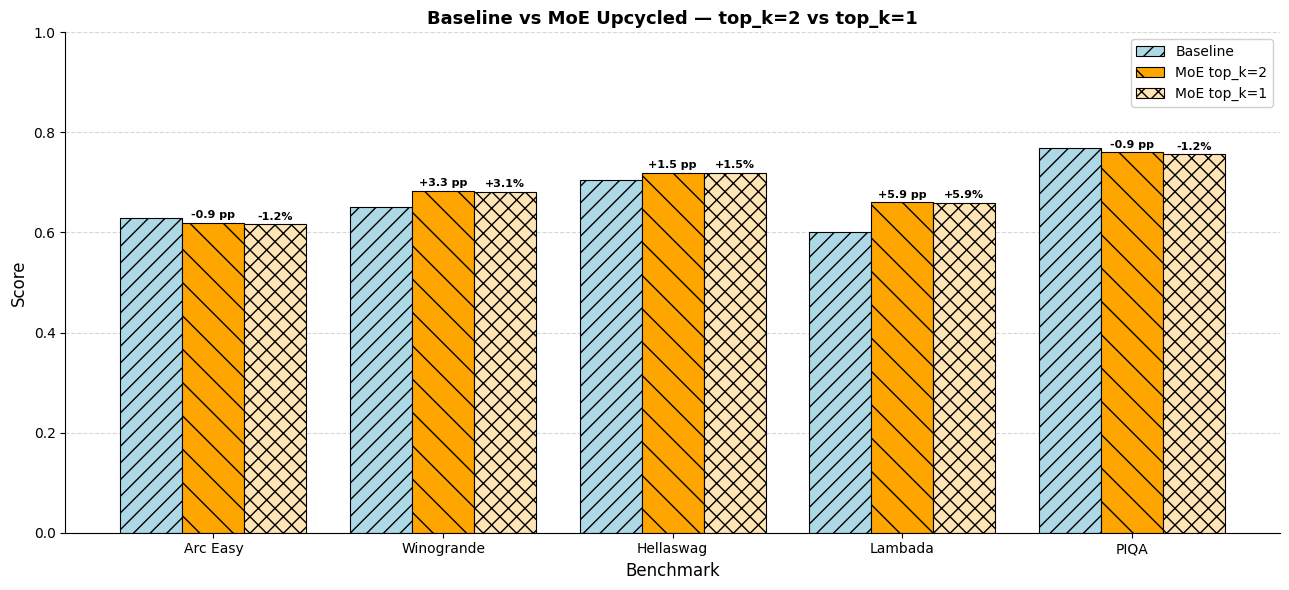

In [54]:
if RUN_FULL_BENCHMARKS:
    x     = np.arange(len(task_labels))
    width = 0.27

    fig, ax = plt.subplots(figsize=(13, 6))

    bars_base = ax.bar(
        x - width, base_scores, width,
        label="Baseline",
        color="lightblue", hatch="//", edgecolor="black", linewidth=0.8
    )
    bars_k2 = ax.bar(
        x, k2_scores, width,
        label="MoE top_k=2",
        color="orange", hatch="\\", edgecolor="black", linewidth=0.8
    )
    bars_k1 = ax.bar(
        x + width, k1_scores, width,
        label="MoE top_k=1",
        color="moccasin", hatch="xx", edgecolor="black", linewidth=0.8
    )

    # Annotate MoE bars with % delta vs baseline
    for bar, base, score in zip(bars_k2, base_scores, k2_scores):
        delta = (score - base) * 100 if base else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{delta:+.1f} pp", ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )
    for bar, base, score in zip(bars_k1, base_scores, k1_scores):
        delta = (score - base) * 100 if base else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{delta:+.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )

    ax.set_xlabel("Benchmark",   fontsize=12)
    ax.set_ylabel("Score",       fontsize=12)
    ax.set_title(
        "Baseline vs MoE Upcycled — top_k=2 vs top_k=1",
        fontsize=13, fontweight="bold"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(task_labels)
    ax.set_ylim(0, 1.0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Benchmark chart not available (RUN_FULL_BENCHMARKS=False)")
